<a href="https://colab.research.google.com/github/HemanthKumarA12/Natual_language_Processing/blob/master/sarcasm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import json
import tensorflow as tf


from tensorflow.keras.preprocessing.text import  Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
pwd

'/content'

In [4]:
!wget --no-check-certificate \
    https://storage.googleapis.com/laurencemoroney-blog.appspot.com/sarcasm.json \
    -O /tmp/sarcasm.json

--2020-06-29 05:14:01--  https://storage.googleapis.com/laurencemoroney-blog.appspot.com/sarcasm.json
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.212.128, 172.217.214.128, 108.177.111.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.212.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5643545 (5.4M) [application/json]
Saving to: ‘/tmp/sarcasm.json’

/tmp/sarcasm.json   100%[===================>]   5.38M  --.-KB/s    in 0.04s   

2020-06-29 05:14:01 (123 MB/s) - ‘/tmp/sarcasm.json’ saved [5643545/5643545]



In [5]:
with open("/tmp/sarcasm.json" , 'r') as f:
  datastore= json.load(f)

sentences=[]
labels=[]

In [6]:
for item in datastore:
  sentences.append(item['headline'])
  labels.append(item['is_sarcastic'])

In [9]:
training_sentences=sentences[0:training_size]
testing_sentences=sentences[training_size:]
training_labels=labels[0:training_size]
testing_labels=labels[training_size:]

In [11]:
tokenizer=Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_sentences)

word_index=tokenizer.word_index
training_sequences=tokenizer.texts_to_sequences(training_sentences)
training_padded=pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [13]:
testing_sequences= tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [14]:
import numpy as np
training_padded=np.array(training_padded)
training_labels=np.array(training_labels)
testing_padded=np.array(testing_padded)
testing_labels=np.array(testing_labels)

In [18]:
model=tf.keras.Sequential([
      tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
      tf.keras.layers.GlobalAveragePooling1D(),
      tf.keras.layers.Dense(24,activation='relu'),
      tf.keras.layers.Dense(1,activation='sigmoid')

])

In [19]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
num_epochs=30
history= model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 3s - loss: 0.6739 - accuracy: 0.5709 - val_loss: 0.6199 - val_accuracy: 0.6157
Epoch 2/30
625/625 - 3s - loss: 0.4694 - accuracy: 0.8109 - val_loss: 0.4113 - val_accuracy: 0.8144
Epoch 3/30
625/625 - 3s - loss: 0.3289 - accuracy: 0.8723 - val_loss: 0.3609 - val_accuracy: 0.8468
Epoch 4/30
625/625 - 3s - loss: 0.2738 - accuracy: 0.8942 - val_loss: 0.3464 - val_accuracy: 0.8559
Epoch 5/30
625/625 - 4s - loss: 0.2366 - accuracy: 0.9088 - val_loss: 0.3435 - val_accuracy: 0.8536
Epoch 6/30
625/625 - 3s - loss: 0.2096 - accuracy: 0.9208 - val_loss: 0.3760 - val_accuracy: 0.8401
Epoch 7/30
625/625 - 3s - loss: 0.1882 - accuracy: 0.9277 - val_loss: 0.3521 - val_accuracy: 0.8535
Epoch 8/30
625/625 - 3s - loss: 0.1696 - accuracy: 0.9361 - val_loss: 0.3782 - val_accuracy: 0.8465
Epoch 9/30
625/625 - 3s - loss: 0.1541 - accuracy: 0.9434 - val_loss: 0.3822 - val_accuracy: 0.8517
Epoch 10/30
625/625 - 3s - loss: 0.1398 - accuracy: 0.9503 - val_loss: 0.3902 - val_accuracy: 0.8541

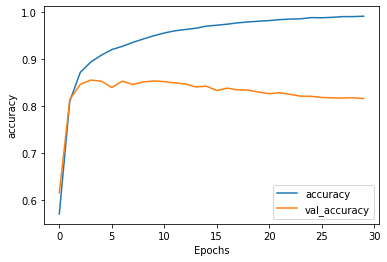

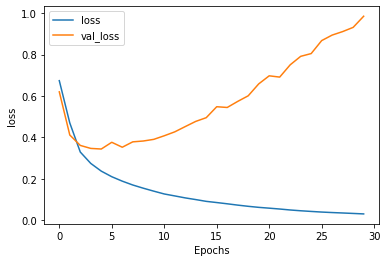

In [22]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel('Epochs')
  plt.ylabel(string)
  plt.legend([string,'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history,"loss")


In [23]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_sentence(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(decode_sentence(training_padded[0]))
print(training_sentences[2])
print(labels[2])

former <OOV> store clerk sues over secret 'black <OOV> for minority shoppers ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
mom starting to fear son's web series closest thing she will have to grandchild
1


In [24]:
e = model.layers[0]
weights = e.get_weights()[0]
print(weights.shape) # shape: (vocab_size, embedding_dim)


(10000, 16)


In [25]:
import io

out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')
for word_num in range(1, vocab_size):
  word = reverse_word_index[word_num]
  embeddings = weights[word_num]
  out_m.write(word + "\n")
  out_v.write('\t'.join([str(x) for x in embeddings]) + "\n")
out_v.close()
out_m.close()

In [26]:
try:
  from google.colab import files
except ImportError:
  pass
else:
  files.download('vecs.tsv')
  files.download('meta.tsv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
sentence = ["granny starting to fear spiders in the garden might be real", "game of thrones season finale showing this sunday night"]
sequences = tokenizer.texts_to_sequences(sentence)
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
print(model.predict(padded))

[[8.5630727e-01]
 [1.5790933e-05]]
